# double cut experiment

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math, scipy, skimage, os
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,

    'svg.fonttype':'none',
    'pdf.fonttype': 42,

    'axes.linewidth': 0.5,

    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,

    'xtick.major.size': 2,
    'ytick.major.size': 2,
    'xtick.major.pad': 1,
    'ytick.major.pad': 1,

    'axes.labelpad': 1
})

In [18]:
from xint_toolbox import nematic_order_filter, nematic_order_of_full_image, sec_to_min_and_sec, create_folder, nematic_to_vector
import tifffile

In [19]:
def parse_range(s):
    a, b = s.split("-")
    return np.array([int(a), int(b)])

# Load data

In [22]:
data_collection = pd.read_excel('B:\\archive\\xtong\\xin home drive\\data_meroblastic\\majority_data_info.xlsx', sheet_name = 'lcii',
                                converters={'rep':int, 'cut_no':int, 'pre_cut_frame_num':int, 'post_cut_frame':int, 'no_analysis_method':str, 'rv_analysis_unit':str, 'rv_analysis_method':str, 'rv_analysis_date':str})
data_collection = data_collection.loc[data_collection['experiment_type'] == 'double_cut']
data_collection

,rep,experiment,experiment_type,cut_type,batch,cut_no,where,orientation,note,note2,...,rv_analysis_method,rv_analysis_date,rv_manual,rv_manual_angle1,rv_manual_angle2,Unnamed: 33,recoiling_analysis1,recoiling_analysis2,recoiling_analysis3,recoiling_analysis4
1019,1019,xin260206_lcii_double_cut,double_cut,NaN,NaN,26,NaN,NaN,1,6-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1020,1020,xin260206_lcii_double_cut,double_cut,NaN,NaN,27,NaN,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1021,1021,xin260206_lcii_double_cut,double_cut,NaN,NaN,28,NaN,NaN,1,6-25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1022,1022,xin260206_lcii_double_cut,double_cut,NaN,NaN,29,NaN,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1023,1023,xin260206_lcii_double_cut,double_cut,NaN,NaN,23,NaN,NaN,1,6-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1024,1024,xin260206_lcii_double_cut,double_cut,NaN,NaN,24,NaN,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1025,1025,xin260206_lcii_double_cut,double_cut,NaN,NaN,25,NaN,NaN,3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1026,1026,xin260206_lcii_double_cut,double_cut,NaN,NaN,21,NaN,NaN,1,6-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1027,1027,xin260206_lcii_double_cut,double_cut,NaN,NaN,22,NaN,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1028,1028,xin260206_lcii_double_cut,double_cut,NaN,NaN,19,NaN,NaN,1,6-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Batch processing

In [16]:
data_subset = data_collection.loc[data_collection['note'] == 1]
nos = []

for i in data_subset.index[:]:
    replicate = data_subset.loc[i]
    print(replicate.rep)

    folder = replicate.experiment
    file = folder + '//' + str(replicate.rep) + '.tif'
    time_interval = replicate.time_interval

    img_raw = tifffile.TiffFile(file).series[0]
    fs, ys, xs = img_raw.shape

    # foi = [0, round(10/time_interval)]
    foi = np.arange(fs)
    
    img = img_raw.asarray(key=foi)

    img = img[:, int(ys/2-30):int(ys/2+30), int(xs/2-30):int(xs/2+30)]
    no = []
    # for f in [0,1]:
    for f in range(fs):
        q_x, q_y, q_xx, q_xy = nematic_order_of_full_image(img[f], windowsize=30, qmin=1/30*30, qmax=15/30*30, print_minmax=False)
        no.append(np.average(-q_xx))
    nos.append(np.array(no))

1019
1021
1023
1026
1028
1030
1033
1036
1039
1042
1045
1047


{'whiskers': [<matplotlib.lines.Line2D at 0x2c6da217750>,
 'caps': [<matplotlib.lines.Line2D at 0x2c6da38c690>,
 'boxes': [<matplotlib.lines.Line2D at 0x2c6da215e50>,
 'medians': [<matplotlib.lines.Line2D at 0x2c6da38c910>,
 'fliers': [<matplotlib.lines.Line2D at 0x2c6da38ca50>,
 'means': []}

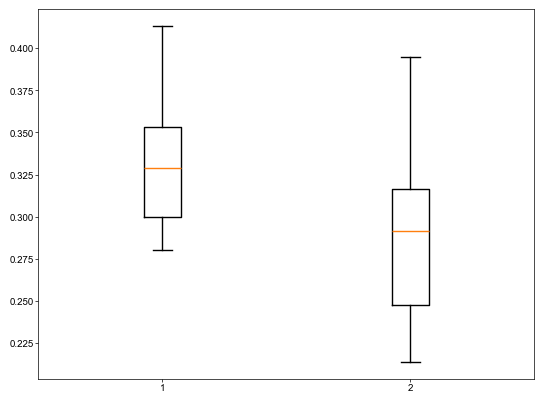

In [6]:
foi = np.array([0, 5 + int(5/time_interval)])
plt.boxplot(np.array([no[foi] for no in nos]))

In [7]:
g1 = np.array([no[foi] for no in nos])[:, 0]
g2 = np.array([no[foi] for no in nos])[:, 1]

# 1. Normality of the *differences*
diff = g1 - g2
_, p_norm = scipy.stats.shapiro(diff)
normal = p_norm > 0.05
print(f"Shapiro p-value (differences): {p_norm:.3f} → {'normal' if normal else 'not normal'}")

# 2. Test
if normal:
    stat, p = scipy.stats.ttest_rel(g1, g2)
    test_name = "Paired t-test"
else:
    stat, p = scipy.stats.wilcoxon(g1, g2)
    test_name = "Wilcoxon signed-rank"

print(f"\n{test_name}: stat={stat:.3f}, p={p:.4f}")

Shapiro p-value (differences): 0.224 → normal

Paired t-test: stat=4.680, p=0.0009


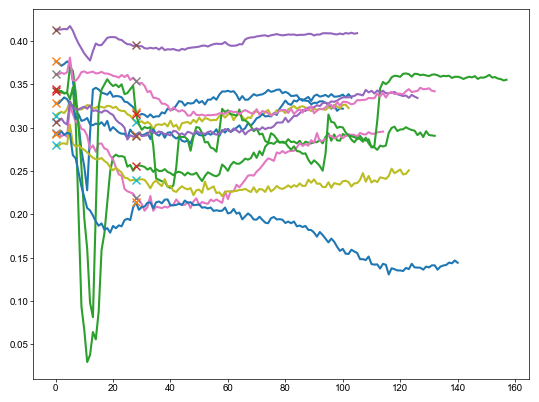

In [8]:
for no in nos:
    plt.plot(no)
    plt.plot(foi, no[foi], 'x')

# Individual movie

## calculate nematic order ($Q_{yy}$)

1019, 1021, 1023, 1026, 1028

--- 1019 ---
0


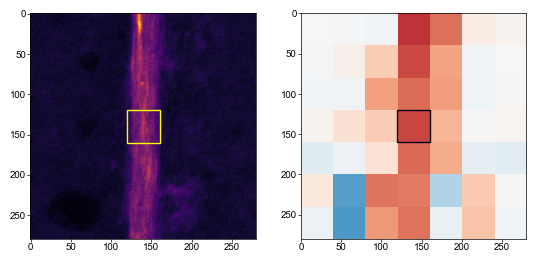

10
20
30
40
50
60
70
80
90
100
 
--- 1021 ---
0


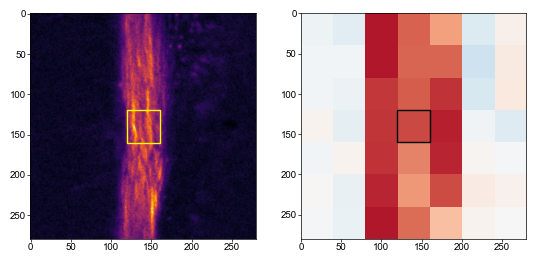

10
20
30
40
50
60
70
80
90
100
110
120
130
 
--- 1023 ---
0


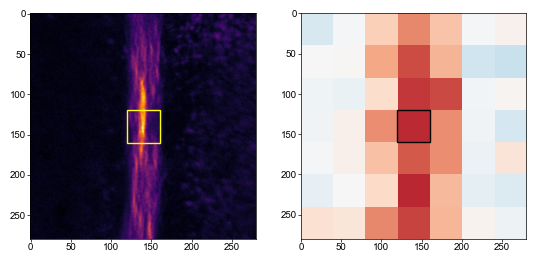

10
20
30
40
50
60
70
80
90
100
 
--- 1026 ---
0


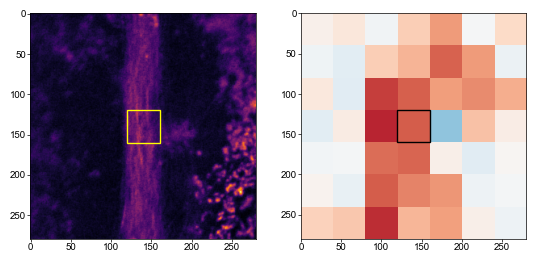

10
20
30
40
50
60
70
80
90
100
110
 
--- 1028 ---
0


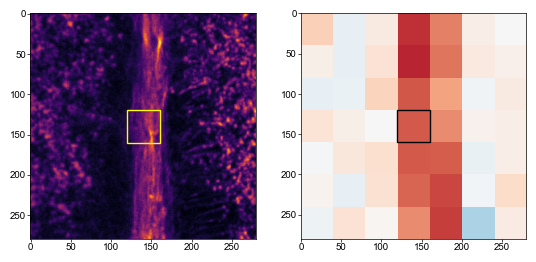

10
20
30
40
50
60
70
80
90
100
 
--- 1030 ---
0


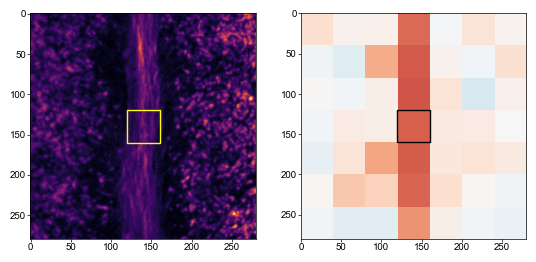

10
20
30
40
50
60
70
80
90
100
 
--- 1033 ---
0


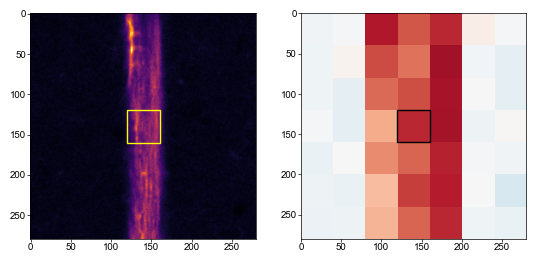

10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
 
--- 1036 ---
0


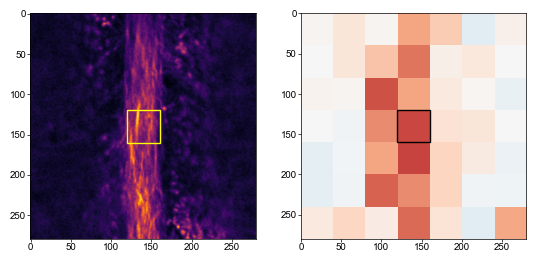

10
20
30
40
50
60
70
80
90
100
110
120
 
--- 1039 ---
0


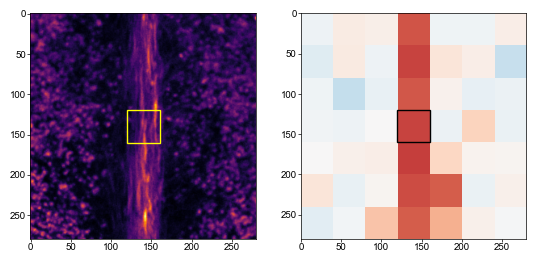

10
20
30
40
50
60
70
80
90
100
110
120
130
 
--- 1042 ---
0


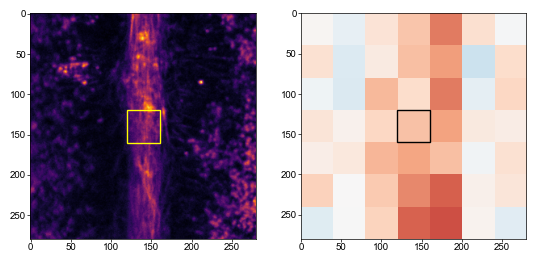

10
20
30
40
50
60
70
80
90
100
110
120
 
--- 1045 ---
0


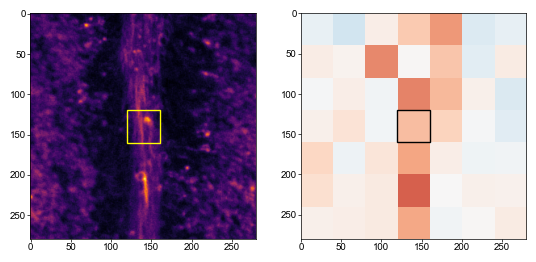

10
20
30
40
50
60
70
80
90
100
110
120
130
140
 
--- 1047 ---
0


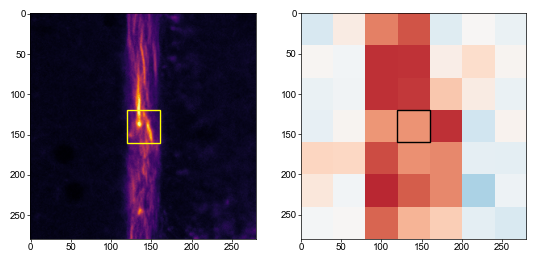

10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
 


In [14]:
# for image_name in [1019]:
# for image_name in [1019, 1020, 1021]:
for image_name in [1019, 1021, 1023, 1026, 1028, 1030, 1033, 1036, 1039, 1042, 1045, 1047]:
    replicate = data_collection.loc[data_collection['rep'] == image_name].iloc[0]
    image_name = str(image_name)

    image_folder = replicate.experiment + '\\'
    image_file = image_folder + image_name + '.tif'

    print('---', image_name, '---')
    image = skimage.io.imread(image_file)[:, 20:300, 20:300]
    frames, ys, xs = image.shape

    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval

    no_qxxs = []
    for f in range(frames):
        if f%10 == 0:
            print(f)
        q_x, q_y, no_qxx, no_qxy = nematic_order_of_full_image(image[f], windowsize=40, qmin=1/30*40, qmax=15/30*40, print_minmax=False)
        qx_step = (q_x[0,1] - q_x[0,0])/2
        qy_step = (q_y[1,0] - q_y[0,0])/2
        if f ==0:
            fig, axs = plt.subplots(1,2)
            axs[0].imshow(image[f], cmap='inferno')
            axs[1].imshow(no_qxx, cmap='RdBu', vmin=-0.5, vmax=0.5, extent=[q_x[0,0] - qx_step, q_x[0, -1] + qx_step, q_y[-1,-1]+qy_step, q_y[0,0]-qy_step])

            axs[0].add_patch(mpl.patches.Rectangle((120, 120), 40, 40, fill=False, edgecolor='yellow'))
            axs[1].add_patch(mpl.patches.Rectangle((120, 120), 40, 40, fill=False, edgecolor='black'))
            plt.show()
        no_qxxs.append(no_qxx)

    no_qxxs = np.array(no_qxxs)
    np.save(image_folder + image_name + '_qxx.npy', no_qxxs)
    print(' ')

## Plot the $Q_{yy}$ as a function of time

--- 1019 ---
[ 5 15]


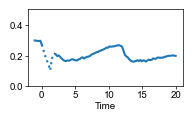

--- 1021 ---
[ 5 24]


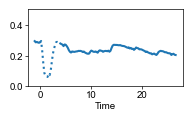

--- 1023 ---
[ 5 20]


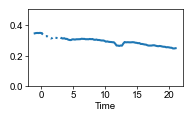

--- 1026 ---
[ 5 17]


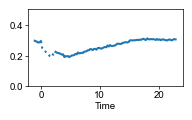

--- 1028 ---
[ 5 11]


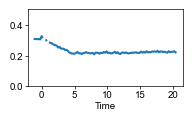

--- 1030 ---
[ 5 11]


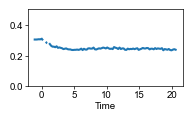

--- 1033 ---
[ 5 20]


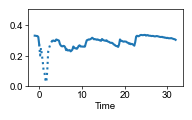

--- 1036 ---
[ 5 23]


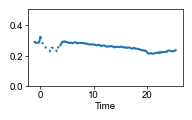

--- 1039 ---
[ 5 11]


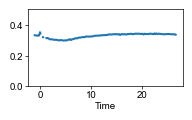

--- 1042 ---
[ 5 11]


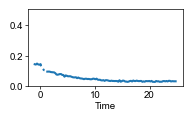

--- 1045 ---
[ 5 11]


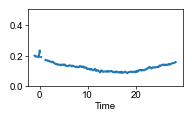

--- 1047 ---
[ 5 41]


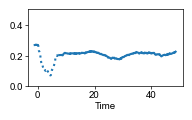

In [23]:
# for image_name in [1019]:
for image_name in [1019, 1021, 1023, 1026, 1028, 1030, 1033, 1036, 1039, 1042, 1045, 1047]:
    replicate = data_collection.loc[data_collection['rep'] == image_name].iloc[0]
    image_name = str(image_name)
    print('---', image_name, '---')

    image_folder = replicate.experiment + '\\'
    image_file = image_folder + image_name + '.tif'

    image = skimage.io.imread(image_file)
    frames, ys, xs = image.shape

    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
    time = (np.arange(frames)-5)*time_interval

    no_qxxs = np.load(image_folder + image_name + '_qxx.npy')
    no_qxxs_time = np.average(no_qxxs[:, 2:5, 3], axis=1)

    refocusing_frames = parse_range(replicate.note2) - 1
    print(refocusing_frames)

    fig, ax = plt.subplots(figsize=[2,1])
    ax.plot(time[:refocusing_frames[0]+1], -no_qxxs_time[:refocusing_frames[0]+1], color='tab:blue', ls='-')
    ax.plot(time[refocusing_frames[0]:refocusing_frames[1]+1], -no_qxxs_time[refocusing_frames[0]:refocusing_frames[1]+1], color='tab:blue', ls=':')
    ax.plot(time[refocusing_frames[1]:], -no_qxxs_time[refocusing_frames[1]:], color='tab:blue', ls='-')
    # ax.set_ylim(0, -np.min(no_qxxs_time)*1.1)
    ax.set_ylim(0, 0.5)
    ax.set_xlabel('Time')
    plt.show()


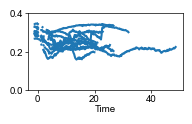

In [54]:
rep_batch, time_batch, no_qxxs_time_batch = [], [], []

fig, ax = plt.subplots(figsize=[2,1])
for image_name in [1019, 1021, 1023, 1026, 1028, 1030, 1033, 1036, 1039, 1042, 1045, 1047]:
    replicate = data_collection.loc[data_collection['rep'] == image_name].iloc[0]
    image_name = str(image_name)
    # print('---', image_name, '---')

    image_folder = replicate.experiment + '\\'
    image_file = image_folder + image_name + '.tif'

    image = skimage.io.imread(image_file)
    frames, ys, xs = image.shape

    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
    time = (np.arange(frames)-5)*time_interval

    no_qxxs = np.load(image_folder + image_name + '_qxx.npy')
    no_qxxs_time = np.average(no_qxxs[:, 2:5, 3], axis=1)

    refocusing_frames = parse_range(replicate.note2) - 1
    no_qxxs_time[refocusing_frames[0]:refocusing_frames[1]] = np.nan
    
    if -no_qxxs_time[0]>=0.2:
        ax.plot(time[:refocusing_frames[0]], -no_qxxs_time[:refocusing_frames[0]], color='tab:blue', ls='-')
        ax.plot(time[[refocusing_frames[0]-1, refocusing_frames[1]]], -no_qxxs_time[[refocusing_frames[0]-1, refocusing_frames[1]]], color='tab:blue', ls=':')
        ax.plot(time[refocusing_frames[1]:], -no_qxxs_time[refocusing_frames[1]:], color='tab:blue', ls='-')
        # ax.set_ylim(0, -np.min(no_qxxs_time)*1.1)

        rep_batch.append(int(image_name))
        time_batch.append(time)
        no_qxxs_time_batch.append(-no_qxxs_time)

ax.set_ylim(0, 0.4)
ax.set_xlabel('Time')
plt.show()

In [63]:
cut_off = np.sum(time_batch[0]<18)
print(cut_off)
no_qxxs_time_mean = np.nanmean([a[:cut_off] for a in no_qxxs_time_batch], axis=0)

91


C:\Users\xtong\AppData\Local\Temp\ipykernel_8828\4247050066.py:3: RuntimeWarning: Mean of empty slice
  no_qxxs_time_mean = np.nanmean([a[:cut_off] for a in no_qxxs_time_batch], axis=0)


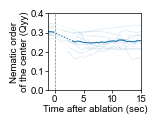

In [49]:
fig, ax = plt.subplots(figsize=[1.2, 1])
for image_name in rep_batch:
    replicate = data_collection.loc[data_collection['rep'] == image_name].iloc[0]
    image_name = str(image_name)
    # print('---', image_name, '---')

    image_folder = replicate.experiment + '\\'
    image_file = image_folder + image_name + '.tif'

    image = skimage.io.imread(image_file)
    frames, ys, xs = image.shape

    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
    time = (np.arange(frames)-5)*time_interval

    no_qxxs = np.load(image_folder + image_name + '_qxx.npy')
    no_qxxs_time = np.average(no_qxxs[:, 2:5, 3], axis=1)

    refocusing_frames = parse_range(replicate.note2) - 1
    no_qxxs_time[refocusing_frames[0]:refocusing_frames[1]] = np.nan

    lw, alpha = 0.4, 0.2
    
    ax.plot(time[:refocusing_frames[0]+1], -no_qxxs_time[:refocusing_frames[0]+1], color='tab:blue', ls='-', lw=lw, alpha=alpha)
    ax.plot(time[[refocusing_frames[0]-1, refocusing_frames[1]]], -no_qxxs_time[[refocusing_frames[0]-1, refocusing_frames[1]]], color='tab:blue', ls=':', lw=lw, alpha=alpha)
    ax.plot(time[refocusing_frames[1]:cut_off], -no_qxxs_time[refocusing_frames[1]:cut_off], color='tab:blue', ls='-', lw=lw, alpha=alpha)
    # ax.set_ylim(0, -np.min(no_qxxs_time)*1.1)

refocusing_frames = [5, 20]
no_qxxs_time_mean[refocusing_frames[0]:refocusing_frames[1]] = np.nan
time = time_batch[0]

lw, alpha = 0.8, 1
ax.plot(time[:refocusing_frames[0]+1], no_qxxs_time_mean[:refocusing_frames[0]+1], color='tab:blue', ls='-', lw=lw, alpha=alpha)
ax.plot(time[[refocusing_frames[0]-1, refocusing_frames[1]]], no_qxxs_time_mean[[refocusing_frames[0]-1, refocusing_frames[1]]], color='tab:blue', ls=':', lw=lw, alpha=alpha)
ax.plot(time[refocusing_frames[1]:cut_off], no_qxxs_time_mean[refocusing_frames[1]:cut_off], color='tab:blue', ls='-', lw=lw, alpha=alpha)

ax.axvline(x=0, color='grey', ls='--', lw=0.5)

ax.set_ylim(0, 0.4)
ax.set_yticks(np.arange(0, 0.5, 0.1))
ax.set_xlim(time_batch[0][0], 15)
ax.set_xticks(np.arange(0, 16, 5))
ax.set_xlabel('Time after ablation (sec)')
ax.set_ylabel('Nematic order\nof the center (Qyy)')

plt.savefig('double_cut_qyy-time.svg')
plt.show()

In [27]:
data_collection.loc[data_collection.rep.isin([1019, 1021, 1023, 1026, 1028, 1030, 1033, 1036, 1039, 1042, 1045, 1047])]

,rep,experiment,experiment_type,cut_type,batch,cut_no,where,orientation,note,note2,...,rv_analysis_method,rv_analysis_date,rv_manual,rv_manual_angle1,rv_manual_angle2,Unnamed: 33,recoiling_analysis1,recoiling_analysis2,recoiling_analysis3,recoiling_analysis4
1019,1019,xin260206_lcii_double_cut,double_cut,NaN,NaN,26,NaN,NaN,1,6-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1021,1021,xin260206_lcii_double_cut,double_cut,NaN,NaN,28,NaN,NaN,1,6-25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1023,1023,xin260206_lcii_double_cut,double_cut,NaN,NaN,23,NaN,NaN,1,6-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1026,1026,xin260206_lcii_double_cut,double_cut,NaN,NaN,21,NaN,NaN,1,6-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1028,1028,xin260206_lcii_double_cut,double_cut,NaN,NaN,19,NaN,NaN,1,6-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1030,1030,xin260206_lcii_double_cut,double_cut,NaN,NaN,16,NaN,NaN,1,6-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1033,1033,xin260206_lcii_double_cut,double_cut,NaN,NaN,12,NaN,NaN,1,6-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1036,1036,xin260206_lcii_double_cut,double_cut,NaN,NaN,9,NaN,NaN,1,6-24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1039,1039,xin260206_lcii_double_cut,double_cut,NaN,NaN,6,NaN,NaN,1,6-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1042,1042,xin260206_lcii_double_cut,double_cut,NaN,NaN,3,NaN,NaN,1,6-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
dfs = []

refocusing_frames = [5, 20]
no_qxxs_time_mean[refocusing_frames[0]:refocusing_frames[1]] = np.nan
time = time_batch[0]

list1 = time[:cut_off]
list2 = ['Refocusing' if np.isnan(x) else x for x in no_qxxs_time_mean]
list3 = ['Mean'] * len(list2)
list4 = [np.nan] * len(list2)

df = pd.DataFrame({'Replicate #': list3, 'Time after ablation (sec)': list1, 'Nematic order of the cable Q_yy': list2, 'Experiment date':list3})
dfs.append(df)

for image_name in rep_batch:
    replicate = data_collection.loc[data_collection['rep'] == image_name].iloc[0]
    image_name = str(image_name)
    # print('---', image_name, '---')

    image_folder = replicate.experiment + '\\'
    image_file = image_folder + image_name + '.tif'

    image = skimage.io.imread(image_file)
    frames, ys, xs = image.shape

    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
    time = (np.arange(frames)-5)*time_interval

    no_qxxs = np.load(image_folder + image_name + '_qxx.npy')
    no_qxxs_time = np.average(no_qxxs[:, 2:5, 3], axis=1)

    refocusing_frames = parse_range(replicate.note2) - 1
    no_qxxs_time[refocusing_frames[0]:refocusing_frames[1]] = np.nan

    list1 = time
    list2 = ['Refocusing' if np.isnan(x) else -x for x in no_qxxs_time]
    list3 = [image_name] * len(list2)
    list4 = [replicate.experiment] * len(list2)

    df = pd.DataFrame({'Replicate #': list3, 'Time after ablation (sec)': list1, 'Nematic order of the cable Q_yy': list2, 'Experiment date':list3})
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
# df_all.fillna('NA', inplace=True)
df_all.to_excel('double_cut_qyy-time_excel_figs4aprime.xlsx', index=False)

## One examplary replicate

--- 1030 ---
[ 5 11]
1 / 104


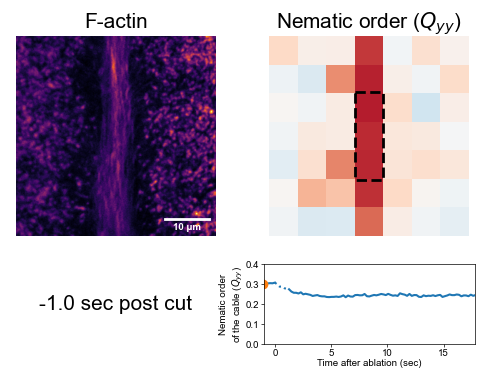

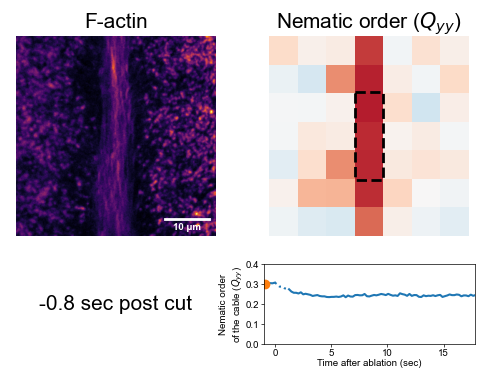

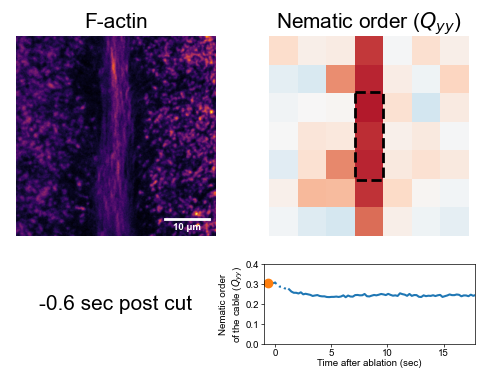

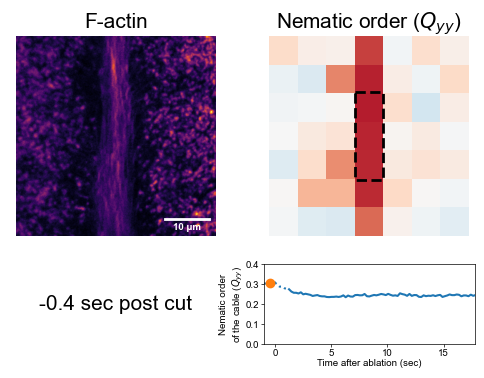

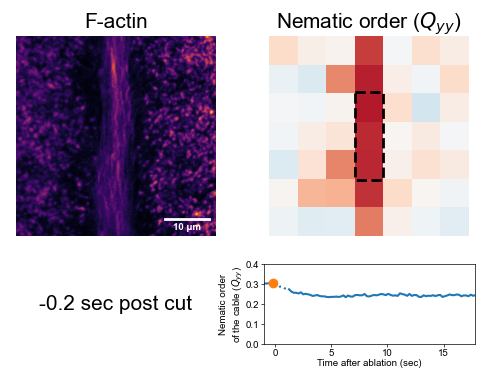

11 / 104
21 / 104
31 / 104
41 / 104
51 / 104
61 / 104
71 / 104
81 / 104
91 / 104


In [47]:
for image_name in [1030]:
# for image_name in rep_batch:
    replicate = data_collection.loc[data_collection['rep'] == image_name].iloc[0]
    image_name = str(image_name)
    print('---', image_name, '---')

    image_folder = replicate.experiment + '\\'
    image_file = image_folder + image_name + '.tif'

    image = skimage.io.imread(image_file)[:,20:300,20:300]
    frames, ys, xs = image.shape

    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
    time = (np.arange(frames)-5)*time_interval
    
    no_qxxs = np.load(image_folder + image_name + '_qxx.npy')
    no_qxxs_time = np.average(no_qxxs[:, 2:5, 3], axis=1)

    q_x, q_y, _, _ = nematic_order_of_full_image(image[0], windowsize=30, qmin=1/30*30, qmax=15/30*30, print_minmax=False)
    qx_step = (q_x[0,1] - q_x[0,0])/2
    qy_step = (q_y[1,0] - q_y[0,0])/2

    refocusing_frames = parse_range(replicate.note2) - 1
    print(refocusing_frames)

    folder_name = image_folder + image_name + '_image_qxx'
    create_folder(folder_name)

    for f in range(cut_off):
    # for f in [3]:
        if f%10 == 0:
            print(f+1, '/', frames)

        fig, axs = plt.subplots(2, 2, figsize=(6, 4), gridspec_kw={"height_ratios": [2, .8]})
        # fig.subplots_adjust(hspace=0.5)

        qxx_vmax = math.ceil(np.max(-no_qxxs_time)*10)*0.1

        axs[0,0].imshow(image[f], cmap='inferno')
        axs[0,1].imshow(no_qxxs[f], cmap='RdBu', vmin=-qxx_vmax, vmax=qxx_vmax, extent=[q_x[0,0] - qx_step, q_x[0, -1] + qx_step, q_y[-1,-1]+qy_step, q_y[0,0]-qy_step])

        # scale bar
        axs[0,0].plot([0+280 - 10 / pixel_size -10, 0+280-10], [0+280-25]*2, color='white', lw=2)
        axs[0,0].text(x = 0+280 - 5 / pixel_size -10, y = 0+280-10, s='10 \u03BCm', fontweight='bold', ha='center', color='white', fontsize=7)

        axs[1,1].plot(time[:refocusing_frames[0]+1], -no_qxxs_time[:refocusing_frames[0]+1], color='tab:blue', ls='-')
        axs[1,1].plot(time[refocusing_frames[0]:refocusing_frames[1]+1], -no_qxxs_time[refocusing_frames[0]:refocusing_frames[1]+1], color='tab:blue', ls=':')
        axs[1,1].plot(time[refocusing_frames[1]:cut_off], -no_qxxs_time[refocusing_frames[1]:cut_off], color='tab:blue', ls='-')
        if f < refocusing_frames[0] or f> refocusing_frames[1]:
            axs[1,1].plot(time[f], -no_qxxs_time[f], 'o', color='tab:orange')
        # axs[1,1].set_aspect(30)
        axs[1,1].set_xlim(-1, 17.8)
        axs[1,1].set_ylim(0, qxx_vmax)
        axs[1,1].set_xticks(np.arange(0,16,5))
        axs[1,1].set_xlabel('Time after ablation (sec)')
        axs[1,1].set_ylabel('Nematic order\nof the cable ($Q_{yy}$)')

        # axs[0,0].add_patch(mpl.patches.Rectangle((120, 80), 40-1, 120-1, fill=False, edgecolor='yellow', lw=2))
        axs[0,1].add_patch(mpl.patches.Rectangle((120, 80), 40-1, 120-1, fill=False, edgecolor='black', ls='--', lw=2))
        if f >= refocusing_frames[0] and f<= refocusing_frames[1]:
            axs[1,0].text(0.5, 0.5, str(round(time[f], 1)) + ' sec post cut\nRefocusing', ha='center', va='center', color='tab:red', fontsize=15)
        else:
            axs[1,0].text(0.5, 0.5, str(round(time[f], 1)) + ' sec post cut', ha='center', va='center', fontsize=15)

        axs[1,0].set_axis_off()
        axs[0,0].set_axis_off()
        axs[0,1].set_axis_off()

        axs[0,0].set_title('F-actin', fontsize=15)
        axs[0,1].set_title(r'Nematic order ($Q_{yy}$)', fontsize=15)

        plt.savefig(folder_name + '/f' + str(f) + '.png', dpi=500, pad_inches = 0)
        if f<5:
            plt.show()
        else:
            plt.close()




## One examplary replicate - panels

In [ ]:
for image_name in [1030]:
    replicate = data_collection.loc[data_collection['rep'] == image_name].iloc[0]
    image_name = str(image_name)
    print('---', image_name, '---')

    image_folder = replicate.experiment + '\\'
    image_file = image_folder + image_name + '.tif'

    image = skimage.io.imread(image_file)[:,20:300,20:300]
    frames, ys, xs = image.shape

    pixel_size, time_interval = replicate.pixel_size, replicate.time_interval
    time = (np.arange(frames)-5)*time_interval
    
    no_qxxs = np.load(image_folder + image_name + '_qxx.npy')
    no_qxxs_time = np.average(no_qxxs[:, 2:5, 3], axis=1)
    qxx_vmax = math.ceil(np.max(-no_qxxs_time)*10)*0.1
    print(qxx_vmax)

    qx_step = (q_x[0,1] - q_x[0,0])/2
    qy_step = (q_y[1,0] - q_y[0,0])/2

    refocusing_frames = parse_range(replicate.note2) - 1
    print(refocusing_frames)

    folder_name = image_folder + image_name + '_image_qxx_montage'
    create_folder(folder_name)

    # for file in os.listdir(folder_name):
    #     os.remove(os.path.join(folder_name, file))

    from xint_toolbox import find_closest
    frames_to_show = find_closest(time, [-1,0,2,4,6,8,10, 12])[1]
    print(frames_to_show+1)
    print(np.min(image), np.max(image)*0.6)

    fig, axs = plt.subplots(2, len(frames_to_show), figsize=[16,4])
    for i, f in enumerate(frames_to_show):
        
        axs[0, i].imshow(image[f], cmap='inferno', vmin=np.min(image), vmax=np.max(image)*0.6)
        # axs[0, i].imshow(image[f], cmap='Greys', vmin=np.min(image), vmax=np.max(image)*0.4)
        axs[1, i].imshow(no_qxxs[f], cmap='RdBu', vmin=-qxx_vmax, vmax=qxx_vmax, extent=[q_x[0,0] - qx_step, q_x[0, -1] + qx_step, q_y[-1,-1]+qy_step, q_y[0,0]-qy_step])

        axs[0, i].set_axis_off()
        axs[1, i].set_axis_off()
    
    axs[0,0].add_patch(mpl.patches.Rectangle((120, 80), 40-1, 120-1, fill=False, edgecolor='yellow', lw=1, ls=':'))
    axs[1,0].add_patch(mpl.patches.Rectangle((120, 80), 40-1, 120-1, fill=False, edgecolor='yellow', lw=1, ls=':'))
    plt.savefig(folder_name + '\\' +str(image_name) + '_double_cut_montage.svg' )
    

In [ ]:
time